# 파일 모델 정보

- 공통 전처리: 데이터 로딩, 라벨 전처리, wafer map 시각화, Resize 전처리, Train/Vaild/Test dataset 분리
- Model 1: Baseline 
- Model 2: 결측치 삭제 + 데이터 증강
- Model 3: Overfitting 대응 
- Model 4: Filter/Pooling 기법 
- Model 5: Polar 변환 Fusion 

---
# 공통: 데이터 로딩 및 전처리

In [24]:
# !pip install scikit-image

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.transform import resize
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import copy

Reference : https://www.kaggle.com/code/loozin/wm-811k-wafermap

In [4]:
path = './data/LSWMD.pkl'

In [5]:
# LSWMD.pkl은 아주 옛날 pandas(0.20 이전) + Python 2 환경에서 pickle된 파일이라,
# 최신 pandas/Python 3에서 pd.read_pickle()로 바로 열면 두 가지 문제가 함께 남
#  1) ModuleNotFoundError: No module named 'pandas.indexes'
#     -> 그 당시 pandas.indexes 였던 경로가 지금은 pandas.core.indexes 로 바뀌었기 때문
#  2) UnicodeDecodeError: 'ascii' codec can't decode byte ...
#     -> Python 2로 pickle된 str이 기본(ascii) 인코딩으로 디코딩되며 깨지기 때문
# -> 옛 모듈 경로를 새 경로로 매핑 + encoding='latin1' 지정으로 우회해서 로드

import pickle

class _RenameUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith('pandas.indexes'):
            module = module.replace('pandas.indexes', 'pandas.core.indexes', 1)
        return super().find_class(module, name)

with open(path, 'rb') as f:
    df = _RenameUnpickler(f, encoding='latin1').load()

print(len(df))

811457


In [6]:
# 라벨(failureType) 전처리
# 원본 데이터의 failureType은 [['Center']] 처럼 리스트 안에 있거나 비어있음
# 이를 일반 문자열로 변환하고, 라벨이 없는 데이터는 제외하는 과정
df['failureNum'] = df.failureType
df['trainTestNum'] = df.trianTestLabel

mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}

# 라벨 정보가 있는 데이터만 추출
df = df.drop(['waferIndex', 'dieSize', 'lotName'], axis=1) # 불필요한 컬럼 제거
df['failureType'] = df['failureType'].apply(lambda x: x[0][0] if len(x) > 0 else 'none')

# 불량 유형별 개수 확인
print("\n<Class Distribution>")
print(df['failureType'].value_counts())


<Class Distribution>
failureType
none         785938
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


In [29]:
def plot_wafer_maps(df, n_samples=3):
    """
    각 불량 유형별로 n_samples개씩 샘플링하여 시각화하는 함수
    """
    failure_types = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']
    
    fig, ax = plt.subplots(len(failure_types), n_samples, figsize=(n_samples*3, len(failure_types)*3))
    
    for i, f_type in enumerate(failure_types):
        # 해당 불량 유형 데이터 필터링
        type_df = df[df['failureType'] == f_type]
        
        # 랜덤 샘플링
        if len(type_df) >= n_samples:
            samples = type_df.sample(n_samples)['waferMap'].values
        else:
            samples = type_df['waferMap'].values
            
        for j in range(n_samples):
            if j < len(samples):
                # 웨이퍼 맵 이미지 출력
                # cmap='inferno': 0(보라/검정-배경), 1(주황-정상), 2(노랑-불량) 등으로 표현됨
                # 직관적인 색상을 위해 사용자 정의 cmap을 써도 좋음
                ax[i, j].imshow(samples[j], cmap='inferno') 
                ax[i, j].set_title(f"{f_type}", fontsize=10)
                ax[i, j].axis('off')
            else:
                ax[i, j].axis('off')
                
    plt.tight_layout()
    plt.show()

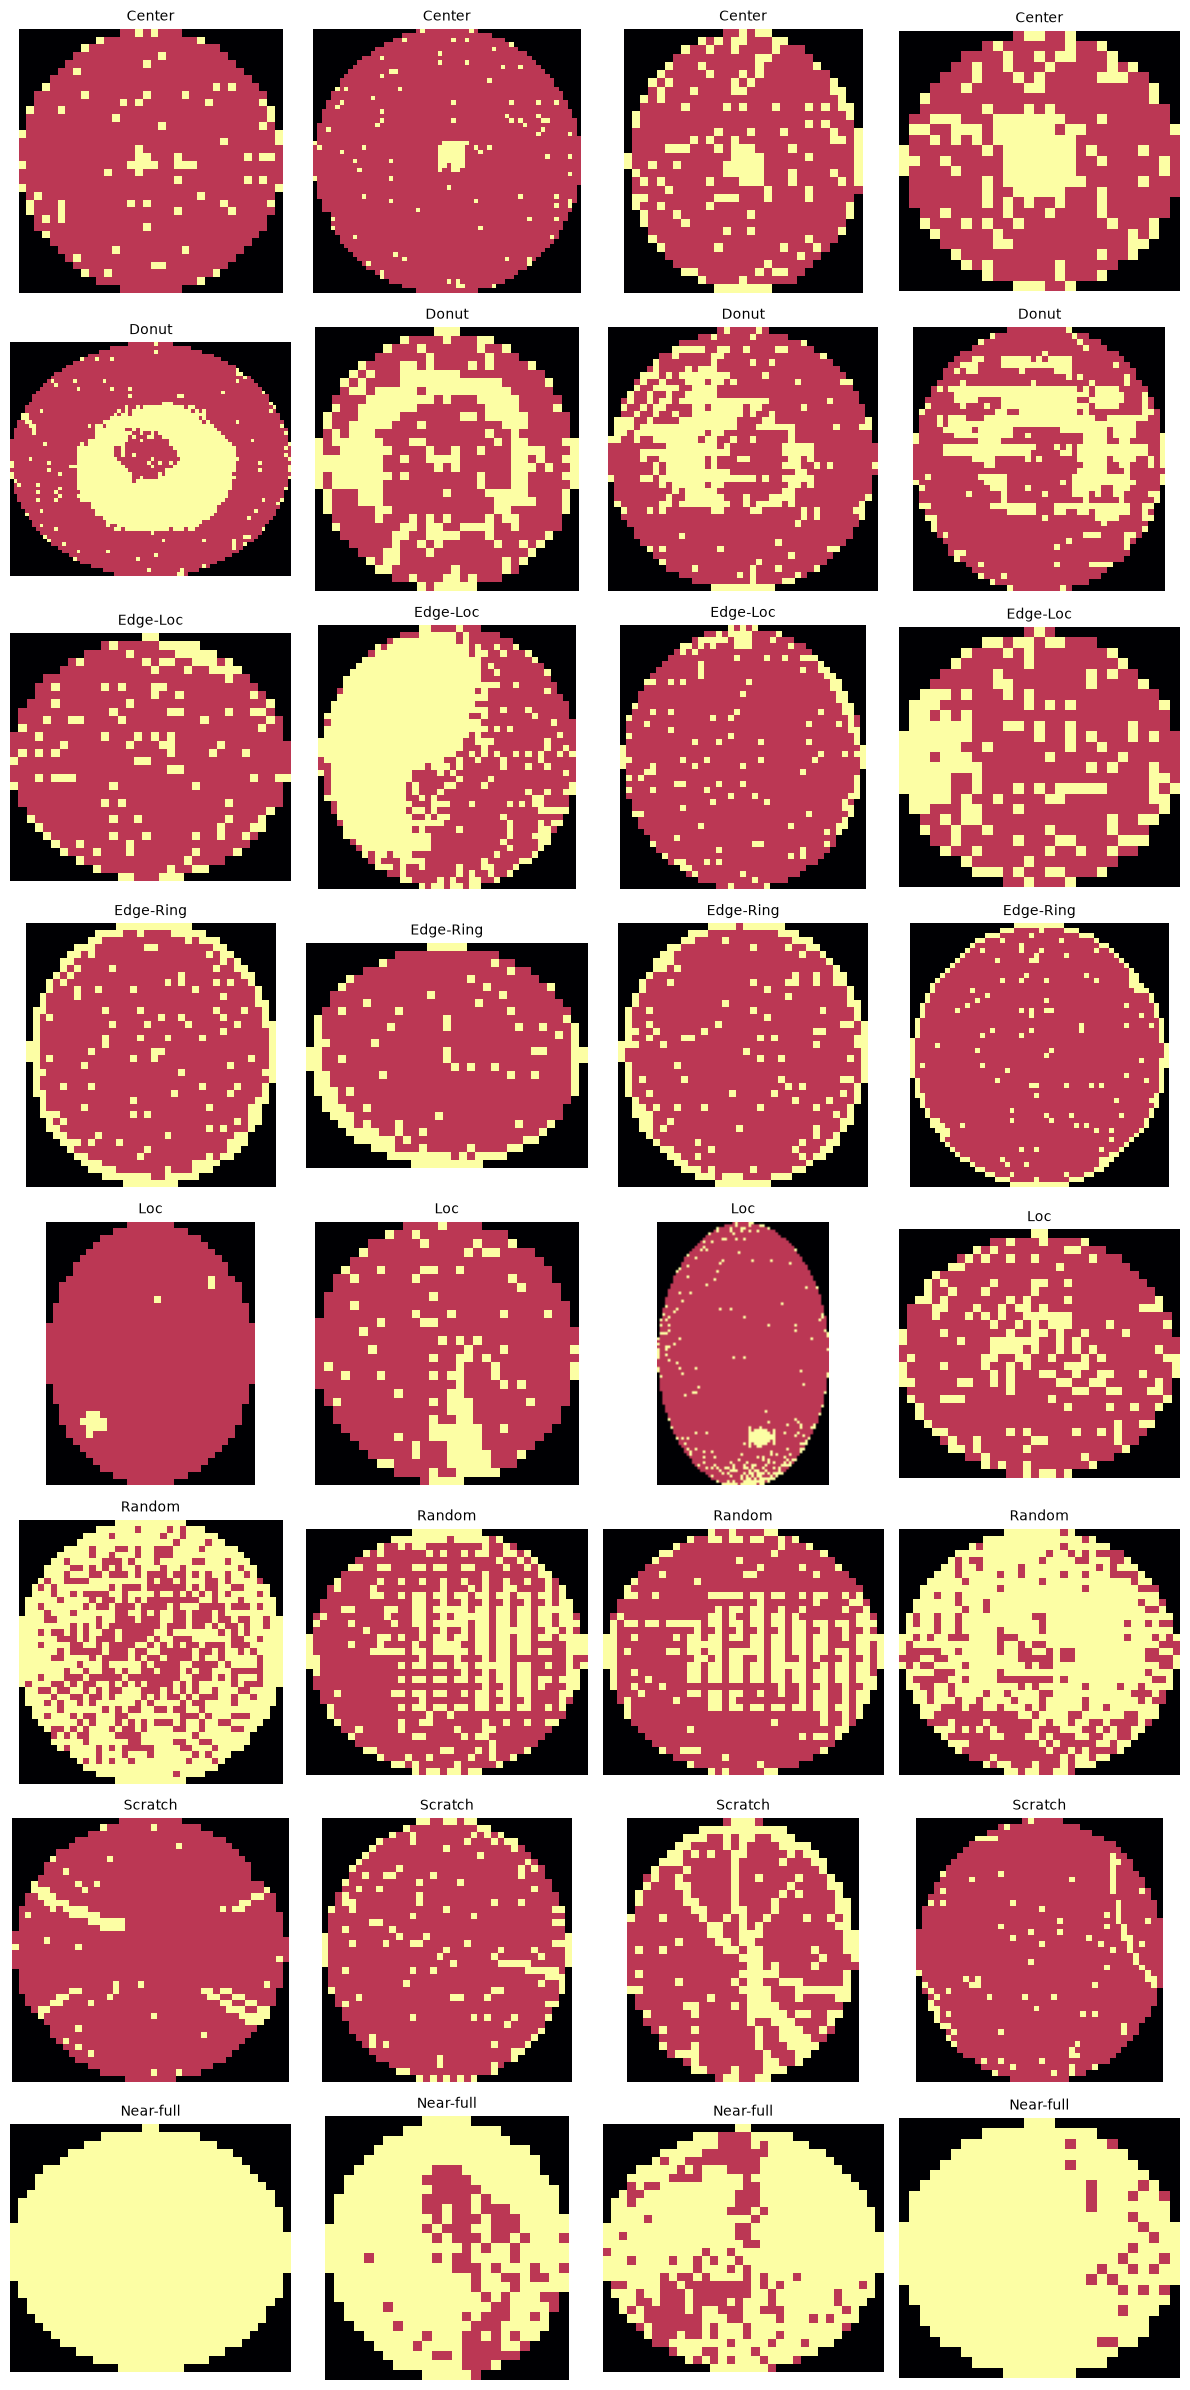

In [30]:
plot_wafer_maps(df, n_samples=4)

In [7]:
# CNN 입력 처리 위한 전처리 (Resize) 
# 웨이퍼크기가 제각각이라 고정된 크기 (64*64)로 맞춤 

def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    CNN 입력용으로 이미지 크기를 통일하는 함수
    OpenCV의 resize 등을 사용해도 무방
    """
    # 웨이퍼 맵을 target_size로 변환 (Nearest Neighbor 보간법 권장: 0,1,2 값을 유지하기 위해)
    # 다만, skimage resize는 기본적으로 float로 반환하므로 주의 필요
    resized_map = resize(wafer_map, target_size, anti_aliasing=False, preserve_range=True, order=0)
    
    # 0, 1, 2 정수값 유지
    return resized_map.astype(int)

In [8]:
# 테스트: 첫 번째 데이터 변환 확인
sample_wafer = df.iloc[0]['waferMap']
resized_wafer = preprocess_wafer_map(sample_wafer)

print(f"\nOriginal shape: {sample_wafer.shape}")
print(f"Resized shape: {resized_wafer.shape}")


Original shape: (45, 48)
Resized shape: (64, 64)


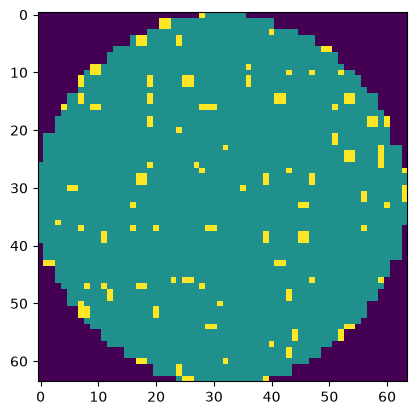

In [33]:
plt.imshow(resized_wafer)

In [34]:
def plot_resized_wafer_maps(df, n_samples=3, target_size=(64, 64)):
    """
    각 불량 유형별로 n_samples개씩 샘플링하여
    원본(Original)과 리사이즈(Resized) 결과를 위아래로 비교 시각화하는 함수
    """
    failure_types = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Random', 'Scratch', 'Near-full']

    # 불량 유형(row) x 2(Original/Resized) 만큼 세로로 배치
    fig, ax = plt.subplots(len(failure_types) * 2, n_samples,
                            figsize=(n_samples * 3, len(failure_types) * 6))

    for i, f_type in enumerate(failure_types):
        # 해당 불량 유형 데이터 필터링
        type_df = df[df['failureType'] == f_type]

        # 랜덤 샘플링
        if len(type_df) >= n_samples:
            samples = type_df.sample(n_samples)['waferMap'].values
        else:
            samples = type_df['waferMap'].values

        row_orig = i * 2
        row_resized = i * 2 + 1

        for j in range(n_samples):
            if j < len(samples):
                original = samples[j]
                resized = preprocess_wafer_map(original, target_size)

                # 원본
                ax[row_orig, j].imshow(original, cmap='inferno')
                ax[row_orig, j].set_title(f"{f_type} (Original {original.shape})", fontsize=9)
                ax[row_orig, j].axis('off')

                # 리사이즈 결과
                ax[row_resized, j].imshow(resized, cmap='inferno')
                ax[row_resized, j].set_title(f"{f_type} (Resized {resized.shape})", fontsize=9)
                ax[row_resized, j].axis('off')
            else:
                ax[row_orig, j].axis('off')
                ax[row_resized, j].axis('off')

    plt.tight_layout()
    plt.show()

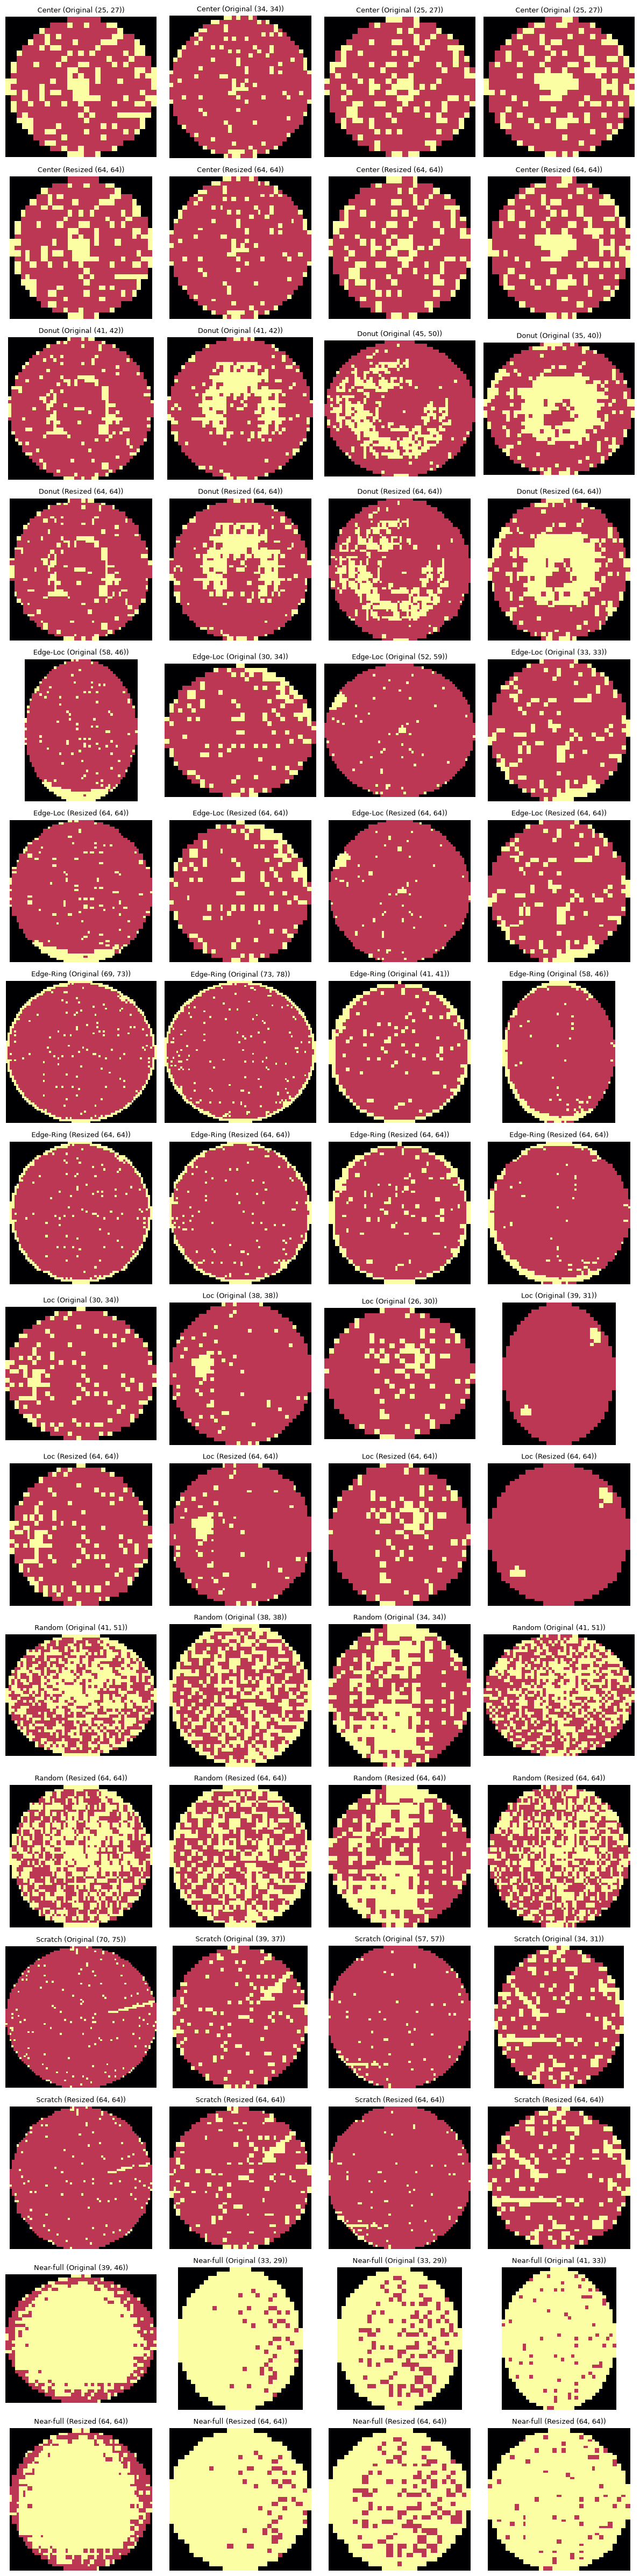

In [35]:
plot_resized_wafer_maps(df, n_samples=4)

---
# Model 1 — Baseline (wafer1)

# Baseline

In [3]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [10]:
tqdm.pandas()

# Diet
# 불량 데이터(Failures)는 모두 유지
# 정상 데이터(None)는 5,000개만 샘플링 
print(f"원본 데이터 크기: {len(df)}")

df_failure = df[df['failureType'] != 'none'].copy()
df_none = df[df['failureType'] == 'none'].sample(n=5000, random_state=42).copy()

df_reduced = pd.concat([df_failure, df_none])
df_reduced = df_reduced.reset_index(drop=True)

print(f"{len(df_reduced)}장으로 축소 (불량: {len(df_failure)}, 정상: 5000)")


# Preprocessing 
def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    웨이퍼 맵 이미지를 target_size로 리사이징.
    - order=0: Nearest Neighbor 보간법을 사용하여 0, 1, 2 정수 라벨이 1.5 같은 실수로 변하지 않도록 함
    - anti_aliasing=False: 경계면이 흐려지는 것을 방지
    """
    # 리사이징 수행
    resized = resize(wafer_map, target_size, 
                     order=0, 
                     preserve_range=True, 
                     anti_aliasing=False)
    
    # float형을 다시 int형으로 변환 (0, 1, 2 유지)
    return resized.astype(int)


print("\n리사이징 및 변환 시작 ...")
resized_list = df_reduced['waferMap'].progress_apply(lambda x: preprocess_wafer_map(x)).tolist()

# Numpy Array 변환 시 'float32' 사용 
# 기본 float64 대신 float32를 쓰면 메모리를 절반만 사용
X = np.array(resized_list, dtype=np.float32)

# CNN 입력 차원 추가 (N, H, W) -> (N, 1, H, W)
# PyTorch: (Batch, Channel, Height, Width)
X = X[:, np.newaxis, :, :]

print("\n=== 최종 결과 확인 ===")
print(f"최종 X 데이터 Shape: {X.shape}") 
print(f"메모리 사용량: {X.nbytes / 1024 / 1024:.2f} MB")

원본 데이터 크기: 811457
30519장으로 축소 (불량: 25519, 정상: 5000)

리사이징 및 변환 시작 ...


100%|██████████| 30519/30519 [00:00<00:00, 33019.25it/s]



=== 최종 결과 확인 ===
최종 X 데이터 Shape: (30519, 1, 64, 64)
메모리 사용량: 476.86 MB


In [11]:
# Y 데이터 (Class Index 사용)
mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}
y = df_reduced['failureType'].replace(mapping_type).values.astype(int)

print(f"y shape: {y.shape}")

y shape: (30519,)


In [12]:
# data set: Train / Valid / Test 분리 (70% / 15% / 15%, stratify 유지)
# 1) 전체 -> Train+Valid(85%) / Test(15%)
# 2) Train+Valid -> Train(70%) / Valid(15%)  (0.15/0.85 ≈ 0.1765)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Train: (21363, 1, 64, 64), Valid: (4578, 1, 64, 64), Test: (4578, 1, 64, 64)


In [41]:
# Custom Dataset 클래스 정의
class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.FloatTensor(images) # Float형 텐서 변환
        self.labels = torch.LongTensor(labels)  # 정수형(Long) 텐서 변환
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [42]:
# DataLoader 생성 (배치 단위 로딩)
train_dataset = WaferDataset(X_train, y_train)
valid_dataset = WaferDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}")

Train batches: 406, Valid batches: 72


In [43]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        # 과제 포인트 1: Conv 레이어 깊이 및 필터 수 조절
        # 입력: (Batch, 1, 64, 64)
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0), # 64 -> 62
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 62 -> 31
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0), # 31 -> 29
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 29 -> 14
        )
        
        # 과제 포인트 2: Fully Connected Layer 구조 변경 (Dropout 추가 등)
        # Flatten 후 크기 계산: 64(채널) * 14(가로) * 14(세로) = 12544
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 64), 
            nn.ReLU(),
            nn.Linear(64, 9) # 9개 클래스
        )
        # 주의: PyTorch CrossEntropyLoss는 내부에 Softmax를 포함하므로, 
        # 모델 끝에 Softmax를 붙이지 않습니다.

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.fc(out)
        return out

model = BaselineCNN().to(device)
print(model)

BaselineCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)


In [ ]:
# Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(epochs):
        # --- Train ---
        model.train() 
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # --- Validation ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(valid_loader)
        val_epoch_acc = 100 * val_correct / val_total
        valid_losses.append(val_epoch_loss)
        valid_accs.append(val_epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
              f"Valid Loss: {val_epoch_loss:.4f}, Valid Acc: {val_epoch_acc:.2f}%")
        
    return train_losses, valid_losses, train_accs, valid_accs

# 학습 실행
print("Starting Training...")
train_losses, valid_losses, train_accs, valid_accs = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=10
)

Starting Training...
Epoch [1/10] Train Loss: 0.8564, Train Acc: 68.66% | Valid Loss: 0.6345, Valid Acc: 77.41%
Epoch [2/10] Train Loss: 0.5258, Train Acc: 81.00% | Valid Loss: 0.4997, Valid Acc: 81.65%
Epoch [3/10] Train Loss: 0.4120, Train Acc: 85.41% | Valid Loss: 0.4598, Valid Acc: 84.14%
Epoch [4/10] Train Loss: 0.3201, Train Acc: 88.84% | Valid Loss: 0.4484, Valid Acc: 84.47%


In [ ]:
# 학습/검증 Loss 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.title('Training / Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Validation 성능 확인 - Accuracy / Recall(Mean) / Macro-F1 + 클래스별 Recall
from sklearn.metrics import recall_score, f1_score

# 예측/정답 수집 함수
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Validation set으로 평가
y_true_val, y_pred_val = get_predictions(model, valid_loader)

# mapping_type(Center:0, Donut:1, ...)의 순서를 그대로 라벨명으로 사용
class_names = [k for k, v in sorted(mapping_type.items(), key=lambda x: x[1])]

valid_acc = 100 * np.mean(y_true_val == y_pred_val)
# recall은 클래스별 recall의 단순 평균(mean) 사용: micro는 다중클래스에서 Accuracy와 동일해지고,
# weighted는 다수 클래스(none)에 쏠려 역시 Accuracy와 거의 같아지므로
# 소수 불량 유형 성능까지 동일 비중으로 반영하는 mean이 의미 있음
per_class_recall = recall_score(y_true_val, y_pred_val, labels=list(range(len(class_names))),
                                 average=None, zero_division=0)
mean_recall = per_class_recall.mean()
macro_f1 = f1_score(y_true_val, y_pred_val, average='macro', zero_division=0)

print("=== Validation Metrics ===")
print(f"Accuracy      : {valid_acc:.2f}%")
print(f"Recall (Mean) : {mean_recall * 100:.2f}%")
print(f"Macro-F1      : {macro_f1 * 100:.2f}%")

# 클래스별 Recall을 컬럼으로 갖는 표
recall_table = pd.DataFrame([per_class_recall * 100], columns=class_names, index=['Recall(%)'])
print("\n=== 클래스별 Recall ===")
print(recall_table.round(2))

# 그래프 1: Accuracy / Recall(Mean) / Macro-F1을 한 그래프에 표시
metric_names = ['Accuracy', 'Recall (Mean)', 'Macro-F1']
metric_values = [valid_acc, mean_recall * 100, macro_f1 * 100]

plt.figure(figsize=(6, 5))
bars = plt.bar(metric_names, metric_values, color=["#3B82F6", "#10B981", "#F59E0B"])
plt.title("Validation Set Metrics")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
for bar, v in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
              f"{v:.2f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# 그래프 2: 클래스별(컬럼별) Recall
plt.figure(figsize=(9, 5))
bars = plt.bar(class_names, per_class_recall * 100, color="#10B981")
plt.title("Class-wise Recall")
plt.xlabel("Failure Type")
plt.ylabel("Recall (%)")
plt.ylim(0, 100)
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha="right")
for bar, r in zip(bars, per_class_recall):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
              f"{r*100:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


---
End of Documents

---
# Model 2 — Train/Valid/Test 분리 + 증강 (wafer2)

# Baseline

In [24]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cpu


In [26]:
tqdm.pandas()

# Diet
# 불량 데이터(Failures)는 모두 유지
# 정상 데이터(None)는 5,000개만 샘플링 
print(f"원본 데이터 크기: {len(df)}")

df_failure = df[df['failureType'] != 'none'].copy()
df_none = df[df['failureType'] == 'none'].sample(n=5000, random_state=42).copy()

df_reduced = pd.concat([df_failure, df_none])
df_reduced = df_reduced.reset_index(drop=True)

print(f"{len(df_reduced)}장으로 축소 (불량: {len(df_failure)}, 정상: 5000)")


# Preprocessing 
def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    웨이퍼 맵 이미지를 target_size로 리사이징.
    - order=0: Nearest Neighbor 보간법을 사용하여 0, 1, 2 정수 라벨이 1.5 같은 실수로 변하지 않도록 함
    - anti_aliasing=False: 경계면이 흐려지는 것을 방지
    """
    # 리사이징 수행
    resized = resize(wafer_map, target_size, 
                     order=0, 
                     preserve_range=True, 
                     anti_aliasing=False)
    
    # float형을 다시 int형으로 변환 (0, 1, 2 유지)
    return resized.astype(int)


print("\n리사이징 및 변환 시작 ...")
resized_list = df_reduced['waferMap'].progress_apply(lambda x: preprocess_wafer_map(x)).tolist()

# Numpy Array 변환 시 'float32' 사용 
# 기본 float64 대신 float32를 쓰면 메모리를 절반만 사용
X = np.array(resized_list, dtype=np.float32)

# CNN 입력 차원 추가 (N, H, W) -> (N, 1, H, W)
# PyTorch: (Batch, Channel, Height, Width)
X = X[:, np.newaxis, :, :]

print("\n=== 최종 결과 확인 ===")
print(f"최종 X 데이터 Shape: {X.shape}") 
print(f"메모리 사용량: {X.nbytes / 1024 / 1024:.2f} MB")

원본 데이터 크기: 172950
30519장으로 축소 (불량: 25519, 정상: 5000)

리사이징 및 변환 시작 ...


100%|██████████| 30519/30519 [00:01<00:00, 27893.60it/s]



=== 최종 결과 확인 ===
최종 X 데이터 Shape: (30519, 1, 64, 64)
메모리 사용량: 476.86 MB


In [27]:
# Y 데이터 (Class Index 사용)
mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}
y = df_reduced['failureType'].replace(mapping_type).values.astype(int)

print(f"y shape: {y.shape}")

y shape: (30519,)


In [28]:
# data set: Train / Valid / Test 분리 (70% / 15% / 15%, stratify 유지)
# 1) 전체 -> Train+Valid(85%) / Test(15%)
# 2) Train+Valid -> Train(70%) / Valid(15%)  (0.15/0.85 ≈ 0.1765)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

Train: (21363, 1, 64, 64), Valid: (4578, 1, 64, 64), Test: (4578, 1, 64, 64)


In [29]:
# 클래스 불균형 완화: 회전/뒤집기 증강 (Train set에만 적용 -> Valid/Test 누수 방지)
# 웨이퍼맵은 원형(대칭) 데이터라 90도 회전 3종 + 좌우/상하 반전 2종 + 대각 반전 2종
# = 원본을 포함해 최대 8가지 변형이 가능 (보간 없이 정수 라벨 0,1,2 그대로 유지됨)
# 목표: 클래스별 4,000개까지 채우되, 한 이미지당 최대 8배(중복 없는 변형 개수)까지만 증강
# -> none(정상)은 제외하고 불량 유형(0~7)에만 적용

TARGET_COUNT = 4000

def rotate_flip_variants(img):
    """(1,H,W) 웨이퍼맵의 원본을 제외한 7가지 대칭 변형을 반환"""
    return [
        np.rot90(img, 1, axes=(1, 2)),
        np.rot90(img, 2, axes=(1, 2)),
        np.rot90(img, 3, axes=(1, 2)),
        np.flip(img, axis=1),
        np.flip(img, axis=2),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=1),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=2),
    ]

print("=== 클래스 불균형 완화 (Train set만 회전/뒤집기 증강) ===")
X_train_aug, y_train_aug = [X_train], [y_train]

for cls in range(8):  # 0~7: 불량 유형만 (8=none 제외)
    cls_images = X_train[y_train == cls]
    n = len(cls_images)
    if n == 0:
        continue

    max_reachable = n * 8  # 원본 1 + 변형 7
    target = min(TARGET_COUNT, max_reachable)
    n_needed = max(0, target - n)

    if n_needed == 0:
        print(f"class {cls}: {n}개 (이미 목표 이상, 증강 생략)")
        continue

    new_imgs = []
    img_i = 0
    while len(new_imgs) < n_needed:
        for v in rotate_flip_variants(cls_images[img_i % n]):
            if len(new_imgs) >= n_needed:
                break
            new_imgs.append(v)
        img_i += 1

    new_imgs = np.array(new_imgs, dtype=np.float32)
    X_train_aug.append(new_imgs)
    y_train_aug.append(np.full(len(new_imgs), cls, dtype=int))
    print(f"class {cls}: {n}개 -> {n + len(new_imgs)}개 (+{len(new_imgs)})")

X_train = np.concatenate(X_train_aug, axis=0)
y_train = np.concatenate(y_train_aug, axis=0)

# 증강 후 순서가 클래스별로 뭉쳐있으므로 셔플
shuffle_idx = np.random.RandomState(42).permutation(len(X_train))
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

print(f"\n증강 후 Train shape: {X_train.shape}")
print(pd.Series(y_train).value_counts().sort_index())

=== 클래스 불균형 완화 (Train set만 회전/뒤집기 증강) ===
class 0: 3006개 -> 4000개 (+994)
class 1: 389개 -> 3112개 (+2723)
class 2: 3632개 -> 4000개 (+368)
class 3: 6776개 (이미 목표 이상, 증강 생략)
class 4: 2515개 -> 4000개 (+1485)
class 5: 104개 -> 832개 (+728)
class 6: 606개 -> 4000개 (+3394)
class 7: 835개 -> 4000개 (+3165)

증강 후 Train shape: (34220, 1, 64, 64)
0    4000
1    3112
2    4000
3    6776
4    4000
5     832
6    4000
7    4000
8    3500
Name: count, dtype: int64


In [30]:
# Custom Dataset 클래스 정의
class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.FloatTensor(images) # Float형 텐서 변환
        self.labels = torch.LongTensor(labels)  # 정수형(Long) 텐서 변환
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [31]:
# DataLoader 생성 (배치 단위 로딩)
train_dataset = WaferDataset(X_train, y_train)
valid_dataset = WaferDataset(X_valid, y_valid)
test_dataset = WaferDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

Train batches: 535, Valid batches: 72, Test batches: 72


In [32]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        
        # 과제 포인트 1: Conv 레이어 깊이 및 필터 수 조절
        # 입력: (Batch, 1, 64, 64)
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0), # 64 -> 62
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 62 -> 31
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0), # 31 -> 29
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 29 -> 14
        )
        
        # 과제 포인트 2: Fully Connected Layer 구조 변경 (Dropout 추가 등)
        # Flatten 후 크기 계산: 64(채널) * 14(가로) * 14(세로) = 12544
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 64), 
            nn.ReLU(),
            nn.Linear(64, 9) # 9개 클래스
        )
        # 주의: PyTorch CrossEntropyLoss는 내부에 Softmax를 포함하므로, 
        # 모델 끝에 Softmax를 붙이지 않습니다.

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.fc(out)
        return out

model = BaselineCNN().to(device)
print(model)

BaselineCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=12544, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=9, bias=True)
  )
)


In [33]:
# Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    for epoch in range(epochs):
        # --- Train ---
        model.train() 
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # --- Validation ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(valid_loader)
        val_epoch_acc = 100 * val_correct / val_total
        valid_losses.append(val_epoch_loss)
        valid_accs.append(val_epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
              f"Valid Loss: {val_epoch_loss:.4f}, Valid Acc: {val_epoch_acc:.2f}%")
        
    return train_losses, valid_losses, train_accs, valid_accs

# 학습 실행
print("Starting Training...")
train_losses, valid_losses, train_accs, valid_accs = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=10
)

Starting Training...
Epoch [1/10] Train Loss: 0.8611, Train Acc: 66.81% | Valid Loss: 0.6435, Valid Acc: 76.21%
Epoch [2/10] Train Loss: 0.5585, Train Acc: 78.66% | Valid Loss: 0.6091, Valid Acc: 76.58%
Epoch [3/10] Train Loss: 0.4514, Train Acc: 82.76% | Valid Loss: 0.5754, Valid Acc: 79.16%
Epoch [4/10] Train Loss: 0.3541, Train Acc: 86.85% | Valid Loss: 0.4599, Valid Acc: 83.62%
Epoch [5/10] Train Loss: 0.2729, Train Acc: 90.09% | Valid Loss: 0.4588, Valid Acc: 83.07%
Epoch [6/10] Train Loss: 0.2069, Train Acc: 92.56% | Valid Loss: 0.4759, Valid Acc: 83.18%
Epoch [7/10] Train Loss: 0.1607, Train Acc: 94.29% | Valid Loss: 0.5882, Valid Acc: 81.13%
Epoch [8/10] Train Loss: 0.1224, Train Acc: 95.63% | Valid Loss: 0.4968, Valid Acc: 84.62%
Epoch [9/10] Train Loss: 0.0884, Train Acc: 97.04% | Valid Loss: 0.6102, Valid Acc: 84.16%
Epoch [10/10] Train Loss: 0.0664, Train Acc: 97.88% | Valid Loss: 0.5557, Valid Acc: 85.02%



Final Test Accuracy: 84.75%


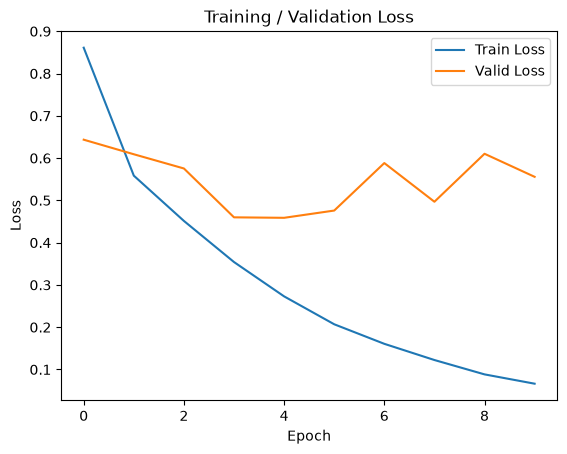

In [34]:
# 테스트 데이터 평가 함수
def evaluate_model(model, test_loader):
    model.eval() 
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    return acc

# 최종 성능 확인 (Test set은 학습/검증에 전혀 관여하지 않은 순수 홀드아웃)
test_acc = evaluate_model(model, test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# 학습/검증 Loss 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.title('Training / Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

=== 불량 유형별 Recall ===
Center      : 93.48%
Donut       : 93.98%
Edge-Loc    : 79.33%
Edge-Ring   : 97.18%
Loc         : 73.10%
Near-full   : 100.00%
Random      : 89.23%
Scratch     : 34.08%
none        : 77.07%

=== Classification Report ===
              precision    recall  f1-score   support

      Center     0.9436    0.9348    0.9392       644
       Donut     0.7500    0.9398    0.8342        83
    Edge-Loc     0.7954    0.7933    0.7943       779
   Edge-Ring     0.9812    0.9718    0.9765      1452
         Loc     0.6355    0.7310    0.6799       539
   Near-full     0.8462    1.0000    0.9167        22
      Random     0.9206    0.8923    0.9062       130
     Scratch     0.4919    0.3408    0.4026       179
        none     0.7972    0.7707    0.7837       750

    accuracy                         0.8475      4578
   macro avg     0.7957    0.8194    0.8037      4578
weighted avg     0.8478    0.8475    0.8464      4578



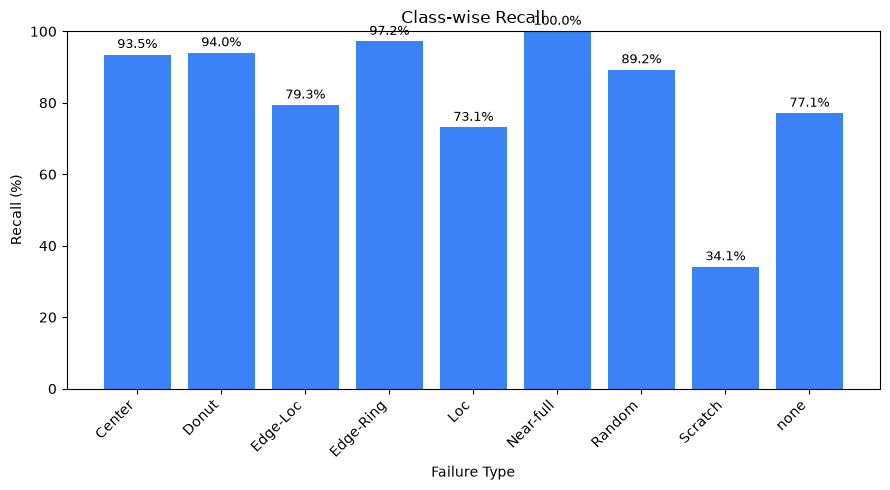

In [35]:
from sklearn.metrics import classification_report, recall_score, confusion_matrix
import numpy as np

# 클래스별 recall 계산 함수
def get_predictions(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# 전체 예측/정답 수집
y_true, y_pred = get_predictions(model, test_loader)

# mapping_type(Center:0, Donut:1, ...)의 순서를 그대로 라벨명으로 사용
class_names = [k for k, v in sorted(mapping_type.items(), key=lambda x: x[1])]

# 클래스별 recall (labels=0~8 순서 고정하여 mapping_type과 정렬 보장)
per_class_recall = recall_score(y_true, y_pred, labels=list(range(len(class_names))), average=None)

print("=== 불량 유형별 Recall ===")
for name, r in zip(class_names, per_class_recall):
    print(f"{name:12s}: {r*100:.2f}%")

# 전체 리포트 (precision/recall/f1 한 번에 확인)
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))

# 시각화
plt.figure(figsize=(9, 5))
bars = plt.bar(class_names, per_class_recall * 100, color="#3B82F6")
plt.title("Class-wise Recall")
plt.xlabel("Failure Type")          # 불량 유형 x축 라벨
plt.ylabel("Recall (%)")
plt.ylim(0, 100)
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha="right")

# 막대 위에 값 표시
for bar, r in zip(bars, per_class_recall):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
              f"{r*100:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


---
End of Documents

---
# Model 3 — Overfitting 대응 (wafer3)

# Baseline

In [ ]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
tqdm.pandas()

# Diet
# 불량 데이터(Failures)는 모두 유지
# 정상 데이터(None)는 5,000개만 샘플링 
print(f"원본 데이터 크기: {len(df)}")

df_failure = df[df['failureType'] != 'none'].copy()
df_none = df[df['failureType'] == 'none'].sample(n=5000, random_state=42).copy()

df_reduced = pd.concat([df_failure, df_none])
df_reduced = df_reduced.reset_index(drop=True)

print(f"{len(df_reduced)}장으로 축소 (불량: {len(df_failure)}, 정상: 5000)")


# Preprocessing 
def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    웨이퍼 맵 이미지를 target_size로 리사이징.
    - order=0: Nearest Neighbor 보간법을 사용하여 0, 1, 2 정수 라벨이 1.5 같은 실수로 변하지 않도록 함
    - anti_aliasing=False: 경계면이 흐려지는 것을 방지
    """
    # 리사이징 수행
    resized = resize(wafer_map, target_size, 
                     order=0, 
                     preserve_range=True, 
                     anti_aliasing=False)
    
    # float형을 다시 int형으로 변환 (0, 1, 2 유지)
    return resized.astype(int)


print("\n리사이징 및 변환 시작 ...")
resized_list = df_reduced['waferMap'].progress_apply(lambda x: preprocess_wafer_map(x)).tolist()

# Numpy Array 변환 시 'float32' 사용 
# 기본 float64 대신 float32를 쓰면 메모리를 절반만 사용
X = np.array(resized_list, dtype=np.float32)

# CNN 입력 차원 추가 (N, H, W) -> (N, 1, H, W)
# PyTorch: (Batch, Channel, Height, Width)
X = X[:, np.newaxis, :, :]

print("\n=== 최종 결과 확인 ===")
print(f"최종 X 데이터 Shape: {X.shape}") 
print(f"메모리 사용량: {X.nbytes / 1024 / 1024:.2f} MB")

원본 데이터 크기: 811457
30519장으로 축소 (불량: 25519, 정상: 5000)

리사이징 및 변환 시작 ...


100%|██████████| 30519/30519 [00:01<00:00, 18876.53it/s]



=== 최종 결과 확인 ===
최종 X 데이터 Shape: (30519, 1, 64, 64)
메모리 사용량: 476.86 MB


In [13]:
# Y 데이터 (Class Index 사용)
mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}
y = df_reduced['failureType'].replace(mapping_type).values.astype(int)

print(f"y shape: {y.shape}")

y shape: (30519,)


In [ ]:
# data set: Train / Valid / Test 분리 (70% / 15% / 15%, stratify 유지)
# 1) 전체 -> Train+Valid(85%) / Test(15%)
# 2) Train+Valid -> Train(70%) / Valid(15%)  (0.15/0.85 ≈ 0.1765)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

In [ ]:
# 클래스 불균형 완화: 회전/뒤집기 증강 (Train set에만 적용 -> Valid/Test 누수 방지)
# 웨이퍼맵은 원형(대칭) 데이터라 90도 회전 3종 + 좌우/상하 반전 2종 + 대각 반전 2종
# = 원본을 포함해 최대 8가지 변형이 가능 (보간 없이 정수 라벨 0,1,2 그대로 유지됨)
# 목표: 클래스별 4,000개까지 채우되, 한 이미지당 최대 8배(중복 없는 변형 개수)까지만 증강
# -> none(정상)은 제외하고 불량 유형(0~7)에만 적용

TARGET_COUNT = 4000

def rotate_flip_variants(img):
    """(1,H,W) 웨이퍼맵의 원본을 제외한 7가지 대칭 변형을 반환"""
    return [
        np.rot90(img, 1, axes=(1, 2)),
        np.rot90(img, 2, axes=(1, 2)),
        np.rot90(img, 3, axes=(1, 2)),
        np.flip(img, axis=1),
        np.flip(img, axis=2),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=1),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=2),
    ]

print("=== 클래스 불균형 완화 (Train set만 회전/뒤집기 증강) ===")
X_train_aug, y_train_aug = [X_train], [y_train]

for cls in range(8):  # 0~7: 불량 유형만 (8=none 제외)
    cls_images = X_train[y_train == cls]
    n = len(cls_images)
    if n == 0:
        continue

    max_reachable = n * 8  # 원본 1 + 변형 7
    target = min(TARGET_COUNT, max_reachable)
    n_needed = max(0, target - n)

    if n_needed == 0:
        print(f"class {cls}: {n}개 (이미 목표 이상, 증강 생략)")
        continue

    new_imgs = []
    img_i = 0
    while len(new_imgs) < n_needed:
        for v in rotate_flip_variants(cls_images[img_i % n]):
            if len(new_imgs) >= n_needed:
                break
            new_imgs.append(v)
        img_i += 1

    new_imgs = np.array(new_imgs, dtype=np.float32)
    X_train_aug.append(new_imgs)
    y_train_aug.append(np.full(len(new_imgs), cls, dtype=int))
    print(f"class {cls}: {n}개 -> {n + len(new_imgs)}개 (+{len(new_imgs)})")

X_train = np.concatenate(X_train_aug, axis=0)
y_train = np.concatenate(y_train_aug, axis=0)

# 증강 후 순서가 클래스별로 뭉쳐있으므로 셔플
shuffle_idx = np.random.RandomState(42).permutation(len(X_train))
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

print(f"\n증강 후 Train shape: {X_train.shape}")
print(pd.Series(y_train).value_counts().sort_index())

In [ ]:
# Custom Dataset 클래스 정의
class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.FloatTensor(images) # Float형 텐서 변환
        self.labels = torch.LongTensor(labels)  # 정수형(Long) 텐서 변환
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [ ]:
# DataLoader 생성 (배치 단위 로딩)
train_dataset = WaferDataset(X_train, y_train)
valid_dataset = WaferDataset(X_valid, y_valid)
test_dataset = WaferDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super(BaselineCNN, self).__init__()
        
        # 과제 포인트 1: Conv 레이어 깊이 및 필터 수 조절
        # 입력: (Batch, 1, 64, 64)
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=0), # 64 -> 62
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 62 -> 31
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0), # 31 -> 29
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2) # 29 -> 14
        )
        
        # 과제 포인트 2: Fully Connected Layer 구조 변경 (Dropout 추가로 과적합 완화)
        # Conv 출력에 대한 Dropout (feature map 일부를 랜덤하게 0으로)
        self.dropout_conv = nn.Dropout(0.25)
        
        # Flatten 후 크기 계산: 64(채널) * 14(가로) * 14(세로) = 12544
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 64), 
            nn.ReLU(),
            nn.Dropout(dropout_p),  # FC 레이어 Dropout
            nn.Linear(64, 9) # 9개 클래스
        )
        # 주의: PyTorch CrossEntropyLoss는 내부에 Softmax를 포함하므로, 
        # 모델 끝에 Softmax를 붙이지 않습니다.

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.dropout_conv(out)
        out = self.fc(out)
        return out

model = BaselineCNN().to(device)
print(model)

In [ ]:
# Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 
patience = 3  # early stopping: valid loss가 이 횟수만큼 연속으로 개선되지 않으면 학습 중단

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10, patience=3):
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    # Early Stopping 관련 변수
    best_valid_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train() 
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # --- Validation ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(valid_loader)
        val_epoch_acc = 100 * val_correct / val_total
        valid_losses.append(val_epoch_loss)
        valid_accs.append(val_epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
              f"Valid Loss: {val_epoch_loss:.4f}, Valid Acc: {val_epoch_acc:.2f}%")

        # ---- Early Stopping ----
        # valid loss가 개선되면 best_model_state 갱신, 아니면 patience_counter 증가
        if val_epoch_loss < best_valid_loss:
            best_valid_loss = val_epoch_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1} "
                    f"(best valid loss: {best_valid_loss:.4f})"
                )
                break

    # 가장 valid loss가 낮았던 시점의 가중치로 복원
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return train_losses, valid_losses, train_accs, valid_accs

# 학습 실행
print("Starting Training...")
train_losses, valid_losses, train_accs, valid_accs = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=10, patience=patience
)

In [ ]:
# 테스트 데이터 평가 함수
def evaluate_model(model, test_loader):
    model.eval() 
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    return acc

# 최종 성능 확인 (Test set은 학습/검증에 전혀 관여하지 않은 순수 홀드아웃)
test_acc = evaluate_model(model, test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# 학습/검증 Loss 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.title('Training / Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

---
End of Documents

---
# Model 4 — Filter/Pooling 기법 (wafer4)

# Baseline

In [ ]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
# 필터(Filter) 기법: 고정된 all-ones 컨볼루션으로 국소 불량 밀도(5x5, 11x11) 채널을 추가.
# 배경(0)은 분모에서 제외해 웨이퍼 바깥이 밀도를 왜곡하지 않도록 함 (mask-aware).
def add_density_channels(maps, kernel_sizes=(5, 11)):
    """(N,64,64) 정수 웨이퍼맵 배치 -> (N, 1+len(kernel_sizes), 64, 64): 원본 + 밀도 채널들"""
    x = torch.from_numpy(maps).float().unsqueeze(1)  # (N,1,64,64)
    valid = (x > 0).float()
    failed = (x == 2).float()
    channels = [x]
    for k in kernel_sizes:
        kernel = torch.ones(1, 1, k, k)
        count = F.conv2d(failed, kernel, padding=k // 2)
        n = F.conv2d(valid, kernel, padding=k // 2)
        channels.append(count / n.clamp_min(1) * valid)  # 배경은 0 유지
    return torch.cat(channels, dim=1).numpy()

In [ ]:
tqdm.pandas()

# Diet
# 불량 데이터(Failures)는 모두 유지
# 정상 데이터(None)는 5,000개만 샘플링 
print(f"원본 데이터 크기: {len(df)}")

df_failure = df[df['failureType'] != 'none'].copy()
df_none = df[df['failureType'] == 'none'].sample(n=5000, random_state=42).copy()

df_reduced = pd.concat([df_failure, df_none])
df_reduced = df_reduced.reset_index(drop=True)

print(f"{len(df_reduced)}장으로 축소 (불량: {len(df_failure)}, 정상: 5000)")


# Preprocessing 
def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    웨이퍼 맵 이미지를 target_size로 리사이징.
    - order=0: Nearest Neighbor 보간법을 사용하여 0, 1, 2 정수 라벨이 1.5 같은 실수로 변하지 않도록 함
    - anti_aliasing=False: 경계면이 흐려지는 것을 방지
    """
    # 리사이징 수행
    resized = resize(wafer_map, target_size, 
                     order=0, 
                     preserve_range=True, 
                     anti_aliasing=False)
    
    # float형을 다시 int형으로 변환 (0, 1, 2 유지)
    return resized.astype(int)


print("\n리사이징 및 변환 시작 ...")
resized_list = df_reduced['waferMap'].progress_apply(lambda x: preprocess_wafer_map(x)).tolist()

# Numpy Array 변환 시 'float32' 사용 
# 기본 float64 대신 float32를 쓰면 메모리를 절반만 사용
X = np.array(resized_list, dtype=np.float32)

# CNN 입력 차원 추가 (N, H, W) -> (N, 1, H, W)
# PyTorch: (Batch, Channel, Height, Width)
X = X[:, np.newaxis, :, :]

# 필터(Filter) 기법 적용: 원본 채널에 5x5/11x11 국소 불량 밀도 채널을 추가 (1채널 -> 3채널)
X = add_density_channels(np.array(resized_list))

print("\n=== 최종 결과 확인 ===")
print(f"최종 X 데이터 Shape: {X.shape}") 
print(f"메모리 사용량: {X.nbytes / 1024 / 1024:.2f} MB")

In [13]:
# Y 데이터 (Class Index 사용)
mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}
y = df_reduced['failureType'].replace(mapping_type).values.astype(int)

print(f"y shape: {y.shape}")

y shape: (30519,)


In [ ]:
# data set: Train / Valid / Test 분리 (70% / 15% / 15%, stratify 유지)
# 1) 전체 -> Train+Valid(85%) / Test(15%)
# 2) Train+Valid -> Train(70%) / Valid(15%)  (0.15/0.85 ≈ 0.1765)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")

In [ ]:
# 클래스 불균형 완화: 회전/뒤집기 증강 (Train set에만 적용 -> Valid/Test 누수 방지)
# 웨이퍼맵은 원형(대칭) 데이터라 90도 회전 3종 + 좌우/상하 반전 2종 + 대각 반전 2종
# = 원본을 포함해 최대 8가지 변형이 가능 (보간 없이 정수 라벨 0,1,2 그대로 유지됨)
# 목표: 클래스별 4,000개까지 채우되, 한 이미지당 최대 8배(중복 없는 변형 개수)까지만 증강
# -> none(정상)은 제외하고 불량 유형(0~7)에만 적용

TARGET_COUNT = 4000

def rotate_flip_variants(img):
    """(1,H,W) 웨이퍼맵의 원본을 제외한 7가지 대칭 변형을 반환"""
    return [
        np.rot90(img, 1, axes=(1, 2)),
        np.rot90(img, 2, axes=(1, 2)),
        np.rot90(img, 3, axes=(1, 2)),
        np.flip(img, axis=1),
        np.flip(img, axis=2),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=1),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=2),
    ]

print("=== 클래스 불균형 완화 (Train set만 회전/뒤집기 증강) ===")
X_train_aug, y_train_aug = [X_train], [y_train]

for cls in range(8):  # 0~7: 불량 유형만 (8=none 제외)
    cls_images = X_train[y_train == cls]
    n = len(cls_images)
    if n == 0:
        continue

    max_reachable = n * 8  # 원본 1 + 변형 7
    target = min(TARGET_COUNT, max_reachable)
    n_needed = max(0, target - n)

    if n_needed == 0:
        print(f"class {cls}: {n}개 (이미 목표 이상, 증강 생략)")
        continue

    new_imgs = []
    img_i = 0
    while len(new_imgs) < n_needed:
        for v in rotate_flip_variants(cls_images[img_i % n]):
            if len(new_imgs) >= n_needed:
                break
            new_imgs.append(v)
        img_i += 1

    new_imgs = np.array(new_imgs, dtype=np.float32)
    X_train_aug.append(new_imgs)
    y_train_aug.append(np.full(len(new_imgs), cls, dtype=int))
    print(f"class {cls}: {n}개 -> {n + len(new_imgs)}개 (+{len(new_imgs)})")

X_train = np.concatenate(X_train_aug, axis=0)
y_train = np.concatenate(y_train_aug, axis=0)

# 증강 후 순서가 클래스별로 뭉쳐있으므로 셔플
shuffle_idx = np.random.RandomState(42).permutation(len(X_train))
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]

print(f"\n증강 후 Train shape: {X_train.shape}")
print(pd.Series(y_train).value_counts().sort_index())

In [ ]:
# Custom Dataset 클래스 정의
class WaferDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.FloatTensor(images) # Float형 텐서 변환
        self.labels = torch.LongTensor(labels)  # 정수형(Long) 텐서 변환
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

In [ ]:
# DataLoader 생성 (배치 단위 로딩)
train_dataset = WaferDataset(X_train, y_train)
valid_dataset = WaferDataset(X_valid, y_valid)
test_dataset = WaferDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super(BaselineCNN, self).__init__()
        
        # 과제 포인트 1: Conv 레이어 깊이 및 필터 수 조절
        # 입력: (Batch, 3, 64, 64) - 원본 + 5x5/11x11 밀도 채널 (필터 기법)
        # 풀링: AvgPool 사용 - 밀도 채널의 정보(비율)를 MaxPool보다 잘 보존함 (풀링 기법)
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0), # 64 -> 62
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2) # 62 -> 31
        )
        
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0), # 31 -> 29
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2) # 29 -> 14
        )
        
        # 과제 포인트 2: Fully Connected Layer 구조 변경 (Dropout 추가로 과적합 완화)
        # Conv 출력에 대한 Dropout (feature map 일부를 랜덤하게 0으로)
        self.dropout_conv = nn.Dropout(0.25)
        
        # Flatten 후 크기 계산: 64(채널) * 14(가로) * 14(세로) = 12544
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 64), 
            nn.ReLU(),
            nn.Dropout(dropout_p),  # FC 레이어 Dropout
            nn.Linear(64, 9) # 9개 클래스
        )
        # 주의: PyTorch CrossEntropyLoss는 내부에 Softmax를 포함하므로, 
        # 모델 끝에 Softmax를 붙이지 않습니다.

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.dropout_conv(out)
        out = self.fc(out)
        return out

model = BaselineCNN().to(device)
print(model)

In [ ]:
# Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 
patience = 3  # early stopping: valid loss가 이 횟수만큼 연속으로 개선되지 않으면 학습 중단

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10, patience=3):
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    # Early Stopping 관련 변수
    best_valid_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train() 
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # --- Validation ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(valid_loader)
        val_epoch_acc = 100 * val_correct / val_total
        valid_losses.append(val_epoch_loss)
        valid_accs.append(val_epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
              f"Valid Loss: {val_epoch_loss:.4f}, Valid Acc: {val_epoch_acc:.2f}%")

        # ---- Early Stopping ----
        # valid loss가 개선되면 best_model_state 갱신, 아니면 patience_counter 증가
        if val_epoch_loss < best_valid_loss:
            best_valid_loss = val_epoch_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1} "
                    f"(best valid loss: {best_valid_loss:.4f})"
                )
                break

    # 가장 valid loss가 낮았던 시점의 가중치로 복원
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return train_losses, valid_losses, train_accs, valid_accs

# 학습 실행
print("Starting Training...")
train_losses, valid_losses, train_accs, valid_accs = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=10, patience=patience
)

In [ ]:
# 테스트 데이터 평가 함수
def evaluate_model(model, test_loader):
    model.eval() 
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    return acc

# 최종 성능 확인 (Test set은 학습/검증에 전혀 관여하지 않은 순수 홀드아웃)
test_acc = evaluate_model(model, test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# 학습/검증 Loss 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.title('Training / Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

---
End of Documents

---
# Model 5 — Polar 변환 Fusion (wafer5)

# Baseline

In [2]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [67]:
# 필터(Filter) 기법: 고정된 all-ones 컨볼루션으로 국소 불량 밀도(5x5, 11x11) 채널을 추가.
# 배경(0)은 분모에서 제외해 웨이퍼 바깥이 밀도를 왜곡하지 않도록 함 (mask-aware).
def add_density_channels(maps, kernel_sizes=(5, 11)):
    """(N,64,64) 정수 웨이퍼맵 배치 -> (N, 1+len(kernel_sizes), 64, 64): 원본 + 밀도 채널들"""
    x = torch.from_numpy(maps).float().unsqueeze(1)  # (N,1,64,64)
    valid = (x > 0).float()
    failed = (x == 2).float()
    channels = [x]
    for k in kernel_sizes:
        kernel = torch.ones(1, 1, k, k)
        count = F.conv2d(failed, kernel, padding=k // 2)
        n = F.conv2d(valid, kernel, padding=k // 2)
        channels.append(count / n.clamp_min(1) * valid)  # 배경은 0 유지
    return torch.cat(channels, dim=1).numpy()

In [68]:
tqdm.pandas()

# Diet
# 불량 데이터(Failures)는 모두 유지
# 정상 데이터(None)는 5,000개만 샘플링 
print(f"원본 데이터 크기: {len(df)}")

df_failure = df[df['failureType'] != 'none'].copy()
df_none = df[df['failureType'] == 'none'].sample(n=5000, random_state=42).copy()

df_reduced = pd.concat([df_failure, df_none])
df_reduced = df_reduced.reset_index(drop=True)

print(f"{len(df_reduced)}장으로 축소 (불량: {len(df_failure)}, 정상: 5000)")


# Preprocessing 
def preprocess_wafer_map(wafer_map, target_size=(64, 64)):
    """
    웨이퍼 맵 이미지를 target_size로 리사이징.
    - order=0: Nearest Neighbor 보간법을 사용하여 0, 1, 2 정수 라벨이 1.5 같은 실수로 변하지 않도록 함
    - anti_aliasing=False: 경계면이 흐려지는 것을 방지
    """
    # 리사이징 수행
    resized = resize(wafer_map, target_size, 
                     order=0, 
                     preserve_range=True, 
                     anti_aliasing=False)
    
    # float형을 다시 int형으로 변환 (0, 1, 2 유지)
    return resized.astype(int)


# 극좌표(Polar) 변환: 가로=각도(0~360도, 반시계 방향), 세로=중심에서의 거리
# 다이가 있는 영역의 bounding box로 중심/반지름을 추정하고, 원본 해상도에서 바로 계산
# (Cartesian처럼 보간 없이 최근접 좌표로 0/1/2 값을 그대로 옮김)
def wafer_to_polar(wafer_map, target_size=64):
    w = np.asarray(wafer_map)
    h, width = w.shape
    yy, xx = np.nonzero(w > 0)
    cy, cx = (yy.min() + yy.max()) / 2, (xx.min() + xx.max()) / 2
    radius = max(yy.max() - yy.min() + 1, xx.max() - xx.min() + 1) / 2
    r = (np.arange(target_size) + .5) / target_size * radius
    theta = np.arange(target_size) / target_size * 2 * np.pi
    py = np.rint(cy - r[:, None] * np.sin(theta)).astype(int)
    px = np.rint(cx + r[:, None] * np.cos(theta)).astype(int)
    inside = (py >= 0) & (py < h) & (px >= 0) & (px < width)
    polar = np.zeros((target_size, target_size), dtype=w.dtype)
    polar[inside] = w[py[inside], px[inside]]
    return polar


print("\n리사이징 및 변환 시작 ...")
resized_list = df_reduced['waferMap'].progress_apply(lambda x: preprocess_wafer_map(x)).tolist()

# Numpy Array 변환 시 'float32' 사용 
# 기본 float64 대신 float32를 쓰면 메모리를 절반만 사용
X = np.array(resized_list, dtype=np.float32)

# CNN 입력 차원 추가 (N, H, W) -> (N, 1, H, W)
# PyTorch: (Batch, Channel, Height, Width)
X = X[:, np.newaxis, :, :]

# 필터(Filter) 기법 적용: 원본 채널에 5x5/11x11 국소 불량 밀도 채널을 추가 (1채널 -> 3채널)
X = add_density_channels(np.array(resized_list))

print("\n극좌표 변환 시작 ...")
polar_list = df_reduced['waferMap'].progress_apply(lambda x: wafer_to_polar(x)).tolist()

# 극좌표 맵에도 동일한 필터(밀도) 채널 적용 (1채널 -> 3채널). Fusion에서 Cartesian과 같은 구조의
# 인코더로 처리하기 위함
X_polar = add_density_channels(np.array(polar_list))

print("\n=== 최종 결과 확인 ===")
print(f"최종 X 데이터 Shape: {X.shape} (Cartesian)")
print(f"최종 X 데이터 Shape: {X_polar.shape} (Polar)")
print(f"메모리 사용량: {(X.nbytes + X_polar.nbytes) / 1024 / 1024:.2f} MB")

원본 데이터 크기: 172950
30519장으로 축소 (불량: 25519, 정상: 5000)

리사이징 및 변환 시작 ...


100%|██████████| 30519/30519 [00:01<00:00, 29809.04it/s]



극좌표 변환 시작 ...


100%|██████████| 30519/30519 [00:01<00:00, 17883.21it/s]



=== 최종 결과 확인 ===
최종 X 데이터 Shape: (30519, 3, 64, 64) (Cartesian)
최종 X 데이터 Shape: (30519, 3, 64, 64) (Polar)
메모리 사용량: 2861.16 MB


In [69]:
# Y 데이터 (Class Index 사용)
mapping_type = {
    'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3, 'Loc': 4,
    'Near-full': 5, 'Random': 6, 'Scratch': 7, 'none': 8
}
y = df_reduced['failureType'].replace(mapping_type).values.astype(int)

print(f"y shape: {y.shape}")

y shape: (30519,)


In [70]:
# data set: Train / Valid / Test 분리 (70% / 15% / 15%, stratify 유지)
# 1) 전체 -> Train+Valid(85%) / Test(15%)
# 2) Train+Valid -> Train(70%) / Valid(15%)  (0.15/0.85 ≈ 0.1765)
# X(Cartesian)와 X_polar를 같은 분할로 함께 나눠 두 표현의 샘플 순서를 맞춘다 (Fusion 입력쌍 유지)
X_temp, X_test, Xp_temp, Xp_test, y_temp, y_test = train_test_split(
    X, X_polar, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_valid, Xp_train, Xp_valid, y_train, y_valid = train_test_split(
    X_temp, Xp_temp, y_temp, test_size=0.15 / 0.85, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")
print(f"Train(polar): {Xp_train.shape}, Valid(polar): {Xp_valid.shape}, Test(polar): {Xp_test.shape}")

Train: (21363, 3, 64, 64), Valid: (4578, 3, 64, 64), Test: (4578, 3, 64, 64)
Train(polar): (21363, 3, 64, 64), Valid(polar): (4578, 3, 64, 64), Test(polar): (4578, 3, 64, 64)


In [71]:
# 클래스 불균형 완화: 회전/뒤집기 증강 (Train set에만 적용 -> Valid/Test 누수 방지)
# 웨이퍼맵은 원형(대칭) 데이터라 90도 회전 3종 + 좌우/상하 반전 2종 + 대각 반전 2종
# = 원본을 포함해 최대 8가지 변형이 가능 (보간 없이 정수 라벨 0,1,2 그대로 유지됨)
# 목표: 클래스별 4,000개까지 채우되, 한 이미지당 최대 8배(중복 없는 변형 개수)까지만 증강
# -> none(정상)은 제외하고 불량 유형(0~7)에만 적용

TARGET_COUNT = 4000

def rotate_flip_variants(img):
    """(1,H,W) 웨이퍼맵의 원본을 제외한 7가지 대칭 변형을 반환 (Cartesian)"""
    return [
        np.rot90(img, 1, axes=(1, 2)),
        np.rot90(img, 2, axes=(1, 2)),
        np.rot90(img, 3, axes=(1, 2)),
        np.flip(img, axis=1),
        np.flip(img, axis=2),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=1),
        np.flip(np.rot90(img, 1, axes=(1, 2)), axis=2),
    ]

def rotate_flip_variants_polar(img, size=64):
    """극좌표 맵(축1=반지름, 축2=각도)의 대응 변형. 극좌표는 rot90/flip을 그대로 쓰면
    반지름과 각도 축이 뒤섞여 버리므로, 반지름 축은 두고 각도 축만 원형 이동(회전)·반전(뒤집기)한다.
    rotate_flip_variants와 같은 순서 7가지를 반환하며, 각 변형이 실제로 같은 물리적 회전/반전을
    나타내는지는 합성 웨이퍼로 미리 검증한 offset(회전: size/4 배수, 반전: 0/16/32/48 축)을 사용."""
    j = np.arange(size)
    rolled = [np.roll(img, shift, axis=2) for shift in (size // 4, size // 2, 3 * size // 4)]
    reflected = [img[:, :, (c - j) % size] for c in (0, size // 2, 3 * size // 4, size // 4)]
    return rolled + reflected

print("=== 클래스 불균형 완화 (Train set만 회전/뒤집기 증강, Cartesian/Polar 동기화) ===")
X_train_aug, Xp_train_aug, y_train_aug = [X_train], [Xp_train], [y_train]

for cls in range(8):  # 0~7: 불량 유형만 (8=none 제외)
    cls_images = X_train[y_train == cls]
    cls_images_p = Xp_train[y_train == cls]
    n = len(cls_images)
    if n == 0:
        continue

    max_reachable = n * 8  # 원본 1 + 변형 7
    target = min(TARGET_COUNT, max_reachable)
    n_needed = max(0, target - n)

    if n_needed == 0:
        print(f"class {cls}: {n}개 (이미 목표 이상, 증강 생략)")
        continue

    new_imgs, new_imgs_p = [], []
    img_i = 0
    while len(new_imgs) < n_needed:
        variants = rotate_flip_variants(cls_images[img_i % n])
        variants_p = rotate_flip_variants_polar(cls_images_p[img_i % n])
        for v, vp in zip(variants, variants_p):
            if len(new_imgs) >= n_needed:
                break
            new_imgs.append(v)
            new_imgs_p.append(vp)
        img_i += 1

    new_imgs = np.array(new_imgs, dtype=np.float32)
    new_imgs_p = np.array(new_imgs_p, dtype=np.float32)
    X_train_aug.append(new_imgs)
    Xp_train_aug.append(new_imgs_p)
    y_train_aug.append(np.full(len(new_imgs), cls, dtype=int))
    print(f"class {cls}: {n}개 -> {n + len(new_imgs)}개 (+{len(new_imgs)})")

X_train = np.concatenate(X_train_aug, axis=0)
Xp_train = np.concatenate(Xp_train_aug, axis=0)
y_train = np.concatenate(y_train_aug, axis=0)

# 증강 후 순서가 클래스별로 뭉쳐있으므로 셔플 (Cartesian/Polar/라벨을 같은 인덱스로 함께 섞음)
shuffle_idx = np.random.RandomState(42).permutation(len(X_train))
X_train, Xp_train, y_train = X_train[shuffle_idx], Xp_train[shuffle_idx], y_train[shuffle_idx]

print(f"\n증강 후 Train shape: {X_train.shape}, Polar: {Xp_train.shape}")
print(pd.Series(y_train).value_counts().sort_index())

=== 클래스 불균형 완화 (Train set만 회전/뒤집기 증강, Cartesian/Polar 동기화) ===
class 0: 3006개 -> 4000개 (+994)
class 1: 389개 -> 3112개 (+2723)
class 2: 3632개 -> 4000개 (+368)
class 3: 6776개 (이미 목표 이상, 증강 생략)
class 4: 2515개 -> 4000개 (+1485)
class 5: 104개 -> 832개 (+728)
class 6: 606개 -> 4000개 (+3394)
class 7: 835개 -> 4000개 (+3165)

증강 후 Train shape: (34220, 3, 64, 64), Polar: (34220, 3, 64, 64)
0    4000
1    3112
2    4000
3    6776
4    4000
5     832
6    4000
7    4000
8    3500
Name: count, dtype: int64


In [72]:
# Custom Dataset 클래스 정의 (Fusion: Cartesian/Polar 두 이미지를 함께 반환)
class WaferDataset(Dataset):
    def __init__(self, images, images_polar, labels):
        self.images = torch.FloatTensor(images)             # Float형 텐서 변환 (Cartesian)
        self.images_polar = torch.FloatTensor(images_polar) # Float형 텐서 변환 (Polar)
        self.labels = torch.LongTensor(labels)               # 정수형(Long) 텐서 변환
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.images_polar[idx], self.labels[idx]

In [73]:
# DataLoader 생성 (배치 단위 로딩)
train_dataset = WaferDataset(X_train, Xp_train, y_train)
valid_dataset = WaferDataset(X_valid, Xp_valid, y_valid)
test_dataset = WaferDataset(X_test, Xp_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")

Train batches: 535, Valid batches: 72, Test batches: 72


In [74]:
class WaferEncoder(nn.Module):
    """BaselineCNN의 Conv 파트를 재사용 가능한 인코더로 분리 (Fusion에서 Cartesian/Polar 각각에 사용)"""
    def __init__(self):
        super().__init__()

        # 과제 포인트 1: Conv 레이어 깊이 및 필터 수 조절
        # 입력: (Batch, 3, 64, 64) - 원본 + 5x5/11x11 밀도 채널 (필터 기법)
        # 풀링: AvgPool 사용 - 밀도 채널의 정보(비율)를 MaxPool보다 잘 보존함 (풀링 기법)
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0), # 64 -> 62
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2) # 62 -> 31
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=0), # 31 -> 29
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2) # 29 -> 14
        )

        # 과제 포인트 2: Fully Connected Layer 구조 변경 (Dropout 추가로 과적합 완화)
        # Conv 출력에 대한 Dropout (feature map 일부를 랜덤하게 0으로)
        self.dropout_conv = nn.Dropout(0.25)

        # Flatten 후 크기 계산: 64(채널) * 14(가로) * 14(세로) = 12544 -> 64차원 특징
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 64),
            nn.ReLU(),
        )

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.dropout_conv(out)
        out = self.fc(out)
        return out


class FusionCNN(nn.Module):
    """Cartesian/Polar 두 표현을 각각 WaferEncoder(64차원)로 인코딩한 뒤 특징을 결합(128차원)해 분류"""
    def __init__(self, dropout_p=0.5):
        super(FusionCNN, self).__init__()
        self.encoder_cart = WaferEncoder()
        self.encoder_polar = WaferEncoder()

        # FC 레이어 Dropout 후 9개 클래스로 분류
        # 주의: PyTorch CrossEntropyLoss는 내부에 Softmax를 포함하므로,
        # 모델 끝에 Softmax를 붙이지 않습니다.
        self.head = nn.Sequential(
            nn.Dropout(dropout_p),
            nn.Linear(64 * 2, 9)
        )

    def forward(self, x_cart, x_polar):
        f_cart = self.encoder_cart(x_cart)
        f_polar = self.encoder_polar(x_polar)
        f = torch.cat([f_cart, f_polar], dim=1)
        return self.head(f)

model = FusionCNN().to(device)
print(model)

FusionCNN(
  (encoder_cart): WaferEncoder(
    (layer1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU()
      (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (layer2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU()
      (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (dropout_conv): Dropout(p=0.25, inplace=False)
    (fc): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=12544, out_features=64, bias=True)
      (2): ReLU()
    )
  )
  (encoder_polar): WaferEncoder(
    (layer1): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU()
      (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (layer2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
      (1): ReLU()
      (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    )
    (dropout_conv): Dropout(p=0.25, inplace=

In [75]:
# Training 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 
patience = 3  # early stopping: valid loss가 이 횟수만큼 연속으로 개선되지 않으면 학습 중단

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10, patience=3):
    train_losses, valid_losses = [], []
    train_accs, valid_accs = [], []

    # Early Stopping 관련 변수
    best_valid_loss = float("inf")
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train() 
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, images_polar, labels in train_loader:
            images, images_polar, labels = images.to(device), images_polar.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images, images_polar)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # --- Validation ---
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, images_polar, labels in valid_loader:
                images, images_polar, labels = images.to(device), images_polar.to(device), labels.to(device)
                outputs = model(images, images_polar)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(valid_loader)
        val_epoch_acc = 100 * val_correct / val_total
        valid_losses.append(val_epoch_loss)
        valid_accs.append(val_epoch_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}% | "
              f"Valid Loss: {val_epoch_loss:.4f}, Valid Acc: {val_epoch_acc:.2f}%")

        # ---- Early Stopping ----
        # valid loss가 개선되면 best_model_state 갱신, 아니면 patience_counter 증가
        if val_epoch_loss < best_valid_loss:
            best_valid_loss = val_epoch_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1} "
                    f"(best valid loss: {best_valid_loss:.4f})"
                )
                break

    # 가장 valid loss가 낮았던 시점의 가중치로 복원
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return train_losses, valid_losses, train_accs, valid_accs

# 학습 실행
print("Starting Training...")
train_losses, valid_losses, train_accs, valid_accs = train_model(
    model, train_loader, valid_loader, criterion, optimizer, epochs=10, patience=patience
)

Starting Training...
Epoch [1/10] Train Loss: 0.9146, Train Acc: 64.75% | Valid Loss: 0.6042, Valid Acc: 75.82%
Epoch [2/10] Train Loss: 0.6670, Train Acc: 74.10% | Valid Loss: 0.4983, Valid Acc: 81.96%
Epoch [3/10] Train Loss: 0.5692, Train Acc: 78.13% | Valid Loss: 0.4038, Valid Acc: 84.95%
Epoch [4/10] Train Loss: 0.5132, Train Acc: 80.68% | Valid Loss: 0.3910, Valid Acc: 85.08%
Epoch [5/10] Train Loss: 0.4727, Train Acc: 82.22% | Valid Loss: 0.3488, Valid Acc: 87.20%
Epoch [6/10] Train Loss: 0.4330, Train Acc: 83.71% | Valid Loss: 0.3333, Valid Acc: 87.55%
Epoch [7/10] Train Loss: 0.4141, Train Acc: 84.43% | Valid Loss: 0.3376, Valid Acc: 87.16%
Epoch [8/10] Train Loss: 0.3868, Train Acc: 85.59% | Valid Loss: 0.3300, Valid Acc: 88.23%
Epoch [9/10] Train Loss: 0.3631, Train Acc: 86.37% | Valid Loss: 0.3393, Valid Acc: 88.07%
Epoch [10/10] Train Loss: 0.3394, Train Acc: 87.14% | Valid Loss: 0.3283, Valid Acc: 88.36%



Final Test Accuracy: 87.77%


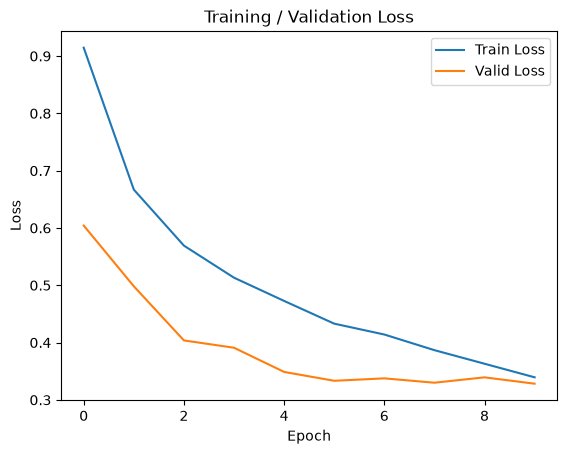

In [76]:
# 테스트 데이터 평가 함수
def evaluate_model(model, test_loader):
    model.eval() 
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, images_polar, labels in test_loader:
            images, images_polar, labels = images.to(device), images_polar.to(device), labels.to(device)
            outputs = model(images, images_polar)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    acc = 100 * correct / total
    return acc

# 최종 성능 확인 (Test set은 학습/검증에 전혀 관여하지 않은 순수 홀드아웃)
test_acc = evaluate_model(model, test_loader)
print(f"\nFinal Test Accuracy: {test_acc:.2f}%")

# 학습/검증 Loss 시각화
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.title('Training / Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

=== Validation Metrics ===
Accuracy      : 88.36%
Recall (Macro): 86.06%
Macro-F1      : 82.85%

=== 클래스별 Recall ===
           Center  Donut  Edge-Loc  Edge-Ring    Loc  Near-full  Random  \
Recall(%)   95.81   98.8     84.19      97.87  66.23       91.3   96.92   

           Scratch  none  
Recall(%)    54.19  89.2  


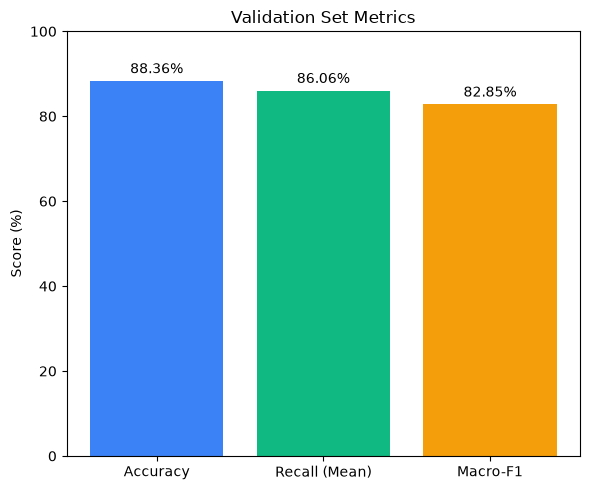

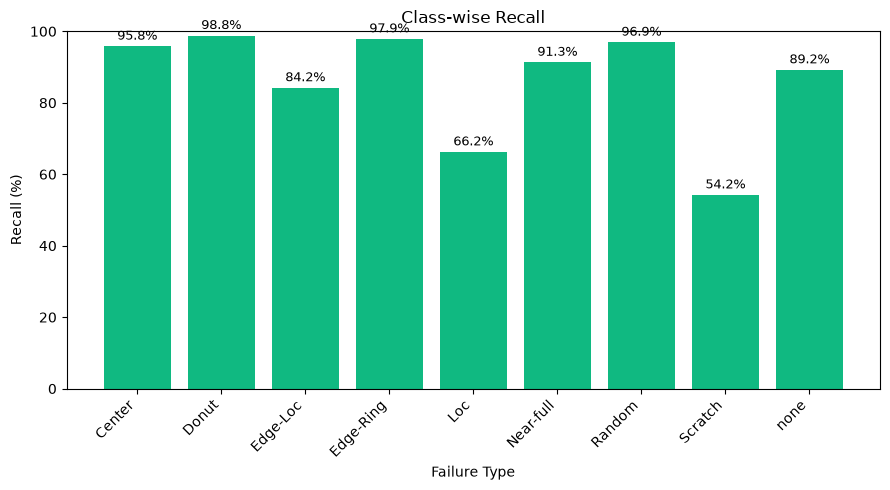

In [ ]:
# Validation 성능 확인 - Accuracy / Recall(Mean) / Macro-F1 + 클래스별 Recall
# (Fusion 모델: loader가 (images, images_polar, labels) 3개를 반환하고
#  model(images, images_polar)처럼 인자를 2개 받으므로 get_predictions도 그에 맞춤)
from sklearn.metrics import recall_score, f1_score

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, images_polar, labels in loader:
            images, images_polar, labels = images.to(device), images_polar.to(device), labels.to(device)
            outputs = model(images, images_polar)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# Validation set으로 평가
y_true_val, y_pred_val = get_predictions(model, valid_loader)

# mapping_type(Center:0, Donut:1, ...)의 순서를 그대로 라벨명으로 사용
class_names = [k for k, v in sorted(mapping_type.items(), key=lambda x: x[1])]

valid_acc = 100 * np.mean(y_true_val == y_pred_val)
# recall/F1은 macro 평균 사용: micro는 다중클래스에서 Accuracy와 동일해지고,
# weighted는 다수 클래스(none)에 쏠려 역시 Accuracy와 거의 같아지므로
# 소수 불량 유형 성능까지 동일 비중으로 반영하는 macro가 의미 있음
per_class_recall = recall_score(y_true_val, y_pred_val, labels=list(range(len(class_names))),
                                 average=None, zero_division=0)
macro_recall = per_class_recall.mean()
macro_f1 = f1_score(y_true_val, y_pred_val, average='macro', zero_division=0)

print("=== Validation Metrics ===")
print(f"Accuracy      : {valid_acc:.2f}%")
print(f"Recall (Mean): {macro_recall * 100:.2f}%")
print(f"Macro-F1      : {macro_f1 * 100:.2f}%")

# 클래스별 Recall을 컬럼으로 갖는 표
recall_table = pd.DataFrame([per_class_recall * 100], columns=class_names, index=['Recall(%)'])
print("\n=== 클래스별 Recall ===")
print(recall_table.round(2))

# 그래프 1: Accuracy / Recall(Macro) / Macro-F1을 한 그래프에 표시
metric_names = ['Accuracy', 'Recall (Mean)', 'Macro-F1']
metric_values = [valid_acc, macro_recall * 100, macro_f1 * 100]

plt.figure(figsize=(6, 5))
bars = plt.bar(metric_names, metric_values, color=["#3B82F6", "#10B981", "#F59E0B"])
plt.title("Validation Set Metrics")
plt.ylabel("Score (%)")
plt.ylim(0, 100)
for bar, v in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
              f"{v:.2f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

# 그래프 2: 클래스별(컬럼별) Recall
plt.figure(figsize=(9, 5))
bars = plt.bar(class_names, per_class_recall * 100, color="#10B981")
plt.title("Class-wise Recall")
plt.xlabel("Failure Type")
plt.ylabel("Recall (%)")
plt.ylim(0, 100)
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha="right")
for bar, r in zip(bars, per_class_recall):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
              f"{r*100:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


=== Test Metrics ===
Accuracy      : 87.77%
Recall (Mean): 85.89%
Macro-F1      : 82.65%

=== 클래스별 Recall (Test) ===
           Center  Donut  Edge-Loc  Edge-Ring    Loc  Near-full  Random  \
Recall(%)   96.27  96.39     80.23      97.66  65.31      90.91   97.69   

           Scratch   none  
Recall(%)    59.22  89.33  

=== 소수 클래스(Near-full, Donut, Random) Recall 평균 ===
Valid-Recall(소수): 95.67%
Test-Recall(소수) : 95.00%


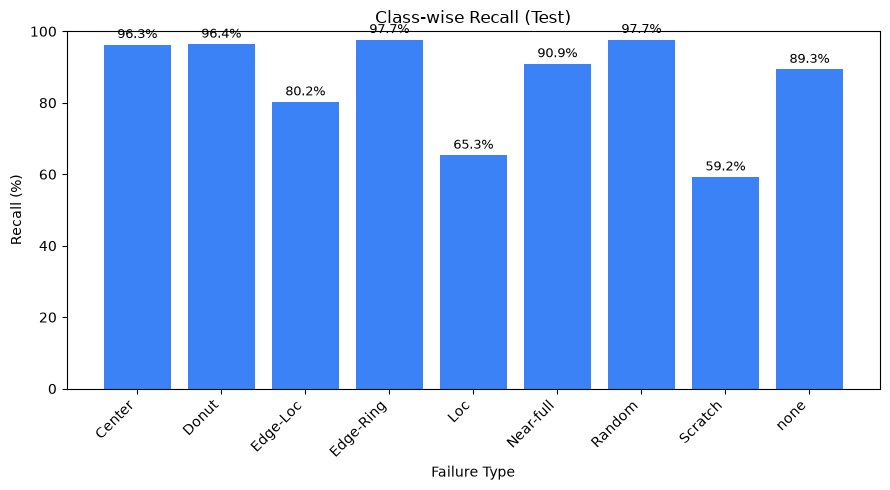

In [83]:
# ===== Test 성능 확인 (Accuracy / Recall(Macro) / Macro-F1 + 클래스별 Recall) =====
# 셀 26의 get_predictions / class_names / mapping_type을 그대로 재사용

y_true_test, y_pred_test = get_predictions(model, test_loader)

test_acc = 100 * np.mean(y_true_test == y_pred_test)
per_class_recall_test = recall_score(
    y_true_test, y_pred_test, labels=list(range(len(class_names))),
    average=None, zero_division=0
)
macro_recall_test = per_class_recall_test.mean()
macro_f1_test = f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)

print("=== Test Metrics ===")
print(f"Accuracy      : {test_acc:.2f}%")
print(f"Recall (Mean): {macro_recall_test * 100:.2f}%")
print(f"Macro-F1      : {macro_f1_test * 100:.2f}%")

recall_table_test = pd.DataFrame(
    [per_class_recall_test * 100], columns=class_names, index=['Recall(%)']
)
print("\n=== 클래스별 Recall (Test) ===")
print(recall_table_test.round(2))

# ===== 소수 클래스(하위 3개, 고정) Recall 평균 =====
MINORITY_CLASSES = ['Near-full', 'Donut', 'Random']
minority_idx = [class_names.index(c) for c in MINORITY_CLASSES]

# Validation: 셀 26에서 이미 계산된 per_class_recall 재사용
valid_minority_recall = per_class_recall[minority_idx].mean()
# Test: 방금 계산한 per_class_recall_test 사용
test_minority_recall = per_class_recall_test[minority_idx].mean()

print(f"\n=== 소수 클래스({', '.join(MINORITY_CLASSES)}) Recall 평균 ===")
print(f"Valid-Recall(소수): {valid_minority_recall * 100:.2f}%")
print(f"Test-Recall(소수) : {test_minority_recall * 100:.2f}%")

# 클래스별 Recall 시각화 (Test)
plt.figure(figsize=(9, 5))
bars = plt.bar(class_names, per_class_recall_test * 100, color="#3B82F6")
plt.title("Class-wise Recall (Test)")
plt.xlabel("Failure Type")
plt.ylabel("Recall (%)")
plt.ylim(0, 100)
plt.xticks(ticks=range(len(class_names)), labels=class_names, rotation=45, ha="right")
for bar, r in zip(bars, per_class_recall_test):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
              f"{r*100:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


---
End of Documents